In [73]:
import numpy as np
from matplotlib import pyplot as plt
import nibabel as nb
from scipy.ndimage import gaussian_filter
from scipy.ndimage import distance_transform_edt
from glob import glob
import sys
import os
sys.path.append('../')
# from slice_structure_identification_functions import compute_signed_distance_weight as compute_signed_distance_weight
# from slice_structure_identification_functions import compute_signed_distance_weight_filled as compute_signed_distance_weight_filled
from slice_registration_functions import apply_coordinate_mapping_2d, compose_coordinate_mappings_2d,compose_mapping_chain_2d

In [95]:
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'
slice_name = 'zefir_0004__Image_03_-_20x_01_cellCount_29'
source_img = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix.nii.gz")

mapping_img = os.path.join(root_dir,f"init_translation_slice_0004/{slice_name}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
comparison_img = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg0nl_ants-def0.nii.gz")

# mapping_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_0_ants-map.nii.gz")
# comparison_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_0_ants-def0.nii.gz")

mapping_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_4_ants-map.nii.gz")
comparison_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_4_ants-def0.nii.gz")

mapping_img3 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
comparison_img3 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-def0.nii.gz")



0.005018246214604005


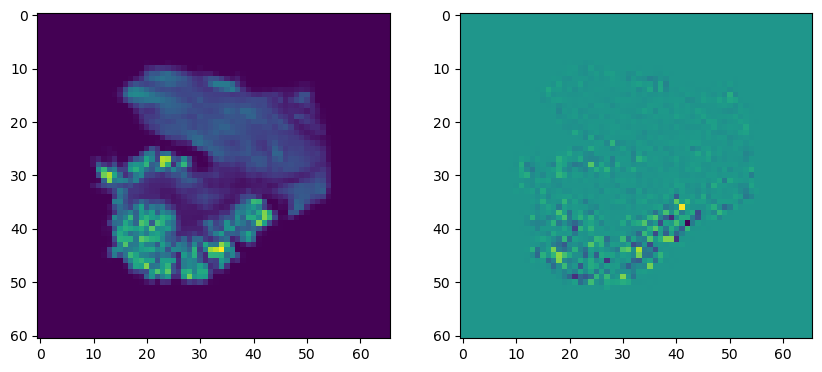

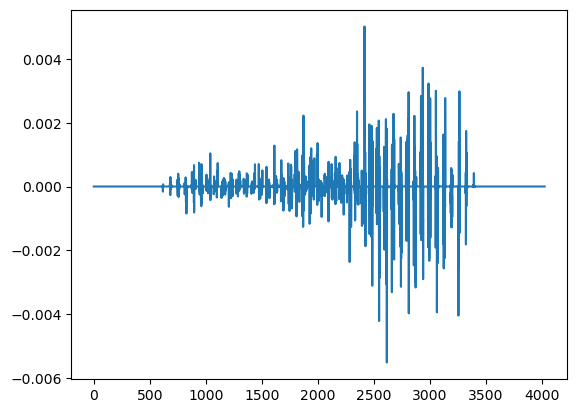

In [115]:
c_map = compose_mapping_chain_2d([mapping_img, mapping_img3])
res2 = apply_coordinate_mapping_2d(nb.load(source_img), c_map)

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(nb.load(comparison_img3).get_fdata())
plt.subplot(1,2,2)
diff = nb.load(comparison_img3).get_fdata()-res2.get_fdata()
plt.imshow(diff)
plt.figure()
plt.plot((nb.load(comparison_img3).get_fdata()-res2.get_fdata()).flatten())
print(np.max(diff))



In [137]:


#import nighres as nr
#import nibabel as nib

root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'
slice_name = 'zefir_0004__Image_03_-_20x_01_cellCount_29'
source_img = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix.nii.gz")

# source_data = nib.load(source_img).get_fdata()

mapping_img = os.path.join(root_dir,f"init_translation_slice_0004/{slice_name}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
comparison_img = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg0nl_ants-def0.nii.gz")

mapping_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_0_ants-map.nii.gz")
comparison_img2 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_rigsyn_0_ants-def0.nii.gz")



mapping_img3 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
comparison_img3 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-def0.nii.gz")

mapping_img4 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
comparison_img4 = os.path.join(root_dir,f"{slice_name}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
# mapping_data = nib.load(mapping_img).get_fdata()

# inverse_mapping_img = os.path.join(root_dir,"init_translation_slice_0020/zefir_0020__Image_11_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-invmap.nii.gz")


# deform = os.path.join(root_dir,"zefir_0020__Image_11_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-def0.nii.gz")
# deform_data = nib.load(deform).get_fdata()


# nr.registration.apply_coordinate_mappings(source_data, mapping_data, output_dir="/data/neuralabc/johmat/phase_ml/tmp/reg_test_output")



In [127]:
# Step-by-step verification
# Step 1: original → coreg0nl
res0 = apply_coordinate_mapping_2d(nb.load(source_img), nb.load(mapping_img))
diff1 = nb.load(comparison_img).get_fdata() - res0.get_fdata()
print(f"Step 1 (coreg0nl) max diff: {np.abs(diff1).max():.6f}")

# Step 2: coreg0nl_def0 → win12 (using actual coreg0nl_def0 as input)
res1_from_def0 = apply_coordinate_mapping_2d(nb.load(comparison_img), nb.load(mapping_img3))
diff2 = nb.load(comparison_img3).get_fdata() - res1_from_def0.get_fdata()
print(f"Step 2 (win12 from coreg0nl_def0) max diff: {np.abs(diff2).max():.6f}")

# Step 3: win12_def0 → groupwise (using actual win12_def0 as input)
res2_from_def0 = apply_coordinate_mapping_2d(nb.load(comparison_img3), nb.load(mapping_img4))
diff3 = nb.load(comparison_img4).get_fdata() - res2_from_def0.get_fdata()
print(f"Step 3 (groupwise from win12_def0) max diff: {np.abs(diff3).max():.6f}")

Step 1 (coreg0nl) max diff: 0.000000
Step 2 (win12 from coreg0nl_def0) max diff: 0.005518
Step 3 (groupwise from win12_def0) max diff: 0.003813


In [119]:
c_map = compose_mapping_chain_2d([mapping_img, mapping_img3, mapping_img4])
res3_from_def0 = apply_coordinate_mapping_2d(nb.load(source_img), c_map)
diff4 = nb.load(comparison_img4).get_fdata() - res3_from_def0.get_fdata()
print(f"Step 4 (rigsyn -> win12 -> groupwise_iter3) max diff: {np.abs(diff4).max():.6f}")

Step 4 (rigsyn -> win12 -> groupwise_iter3) max diff: 830.127195


In [120]:
# Diagnostic: check shapes and value ranges of all maps
for label, path in [("coreg0nl_map", mapping_img), 
                     ("win12_map", mapping_img3), 
                     ("groupwise_map", mapping_img4)]:
    m = nb.load(path).get_fdata()
    print(f"{label}: shape={m.shape}, "
          f"X range=[{m[:,:,0].min():.1f}, {m[:,:,0].max():.1f}], "
          f"Y range=[{m[:,:,1].min():.1f}, {m[:,:,1].max():.1f}]")

# Also check source and def0 images
for label, path in [("source_img", source_img), 
                     ("coreg0nl_def0", comparison_img),
                     ("win12_def0", comparison_img3), 
                     ("groupwise_def0", comparison_img4)]:
    d = nb.load(path).get_fdata()
    print(f"{label}: shape={d.shape}, range=[{d.min():.1f}, {d.max():.1f}]")

# Check intermediate composition
c_map_step1 = compose_coordinate_mappings_2d(nb.load(mapping_img), nb.load(mapping_img3))
print(f"\ncomposed(coreg0nl, win12): shape={c_map_step1.get_fdata().shape}, "
      f"X range=[{c_map_step1.get_fdata()[:,:,0].min():.1f}, {c_map_step1.get_fdata()[:,:,0].max():.1f}], "
      f"Y range=[{c_map_step1.get_fdata()[:,:,1].min():.1f}, {c_map_step1.get_fdata()[:,:,1].max():.1f}]")

# Test 2-step composition only
res_2step = apply_coordinate_mapping_2d(nb.load(source_img), c_map_step1)
diff_2step = nb.load(comparison_img3).get_fdata() - res_2step.get_fdata()
print(f"\n2-step compose (coreg0nl+win12) max diff: {np.abs(diff_2step).max():.6f}")

coreg0nl_map: shape=(61, 66, 2), X range=[0.0, 60.0], Y range=[0.0, 65.0]
win12_map: shape=(61, 66, 2), X range=[0.0, 60.0], Y range=[0.0, 65.0]
groupwise_map: shape=(61, 66, 2), X range=[0.0, 60.0], Y range=[0.0, 65.0]
source_img: shape=(61, 66), range=[0.0, 3723.0]
coreg0nl_def0: shape=(61, 66), range=[0.0, 3723.0]
win12_def0: shape=(61, 66), range=[0.0, 3569.6]
groupwise_def0: shape=(61, 66), range=[0.0, 3427.5]

composed(coreg0nl, win12): shape=(61, 66, 2), X range=[0.0, 60.0], Y range=[0.0, 65.0]

2-step compose (coreg0nl+win12) max diff: 0.005518


Sequential 3-step max diff: 0.004597
Composed 3-step max diff: 830.127195

Worst pixel at (37, 19):
  Expected (groupwise_def0): 1808.3638
  Composed result:           2638.4910
  Sequential result:         1808.3627
  Composed coord: (35.3521, 17.0576)
  M3 coord at worst: (36.8223, 18.7993)

  win12_def0 at M3 coord: 1808.3634
  source at composed coord: 2638.4910

  composed_12 at M3 coord: (35.3521, 17.0576)
  M1 at M3 coord (WRONG - should go through M2): (36.8223, 18.7993)
  M2 at M3 coord: (35.3521, 17.0576)
  M1 at M2(M3) coord (correct chain): (35.3521, 17.0576)


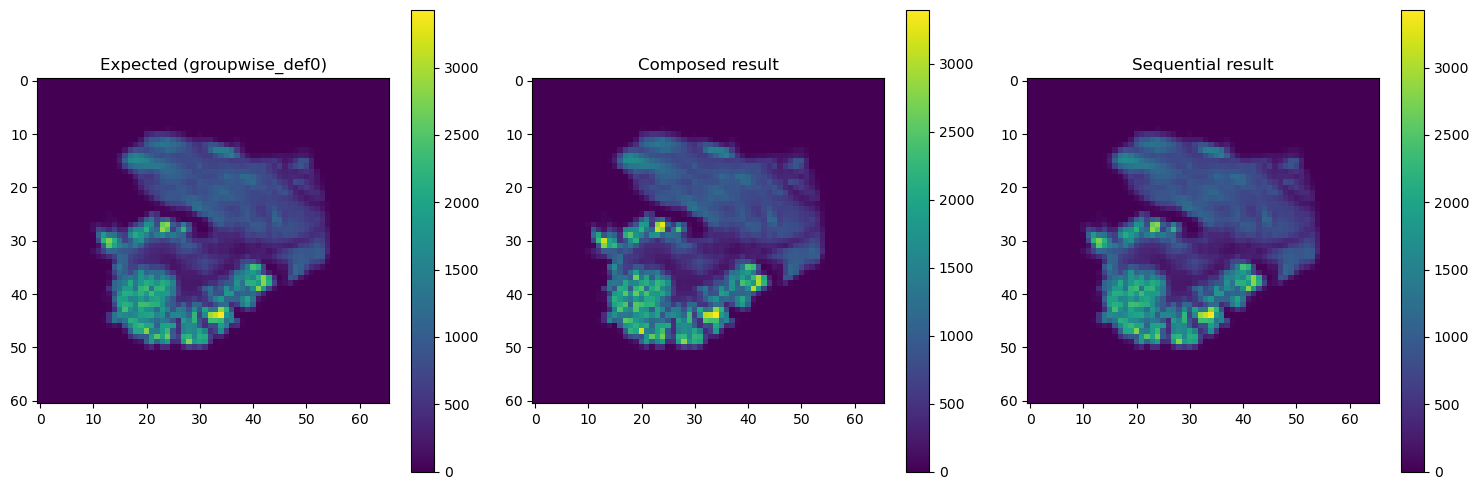

In [128]:
from scipy.ndimage import map_coordinates as mc

# Load all raw data (no NIfTI wrapping)
src = nb.load(source_img).get_fdata()
expected = nb.load(comparison_img4).get_fdata()
m1d = nb.load(mapping_img).get_fdata()    # coreg0nl map
m2d = nb.load(mapping_img3).get_fdata()   # win12 map
m3d = nb.load(mapping_img4).get_fdata()   # groupwise map

# === Test 1: Sequential application (3 interpolation steps) ===
s1 = mc(src, [m1d[:,:,0], m1d[:,:,1]], order=1, mode='constant', cval=0)
s2 = mc(s1, [m2d[:,:,0], m2d[:,:,1]], order=1, mode='constant', cval=0)
s3 = mc(s2, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='constant', cval=0)
print(f"Sequential 3-step max diff: {np.abs(expected - s3).max():.6f}")

# === Test 2: Composed coordinates applied directly ===
cx12 = mc(m1d[:,:,0], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
cy12 = mc(m1d[:,:,1], [m2d[:,:,0], m2d[:,:,1]], order=1, mode='nearest')
cx123 = mc(cx12, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
cy123 = mc(cy12, [m3d[:,:,0], m3d[:,:,1]], order=1, mode='nearest')
result_composed = mc(src, [cx123, cy123], order=1, mode='constant', cval=0)
print(f"Composed 3-step max diff: {np.abs(expected - result_composed).max():.6f}")

# === Test 3: Find the worst pixel and diagnose ===
diffs = np.abs(expected - result_composed)
worst = np.unravel_index(np.argmax(diffs), diffs.shape)
print(f"\nWorst pixel at {worst}:")
print(f"  Expected (groupwise_def0): {expected[worst]:.4f}")
print(f"  Composed result:           {result_composed[worst]:.4f}")
print(f"  Sequential result:         {s3[worst]:.4f}")
print(f"  Composed coord: ({cx123[worst]:.4f}, {cy123[worst]:.4f})")
print(f"  M3 coord at worst: ({m3d[worst[0], worst[1], 0]:.4f}, {m3d[worst[0], worst[1], 1]:.4f})")

# === Test 4: Check what the sequential intermediate looks like at that pixel ===
# What does win12_def0 look like at the M3 coordinate?
win12_def0 = nb.load(comparison_img3).get_fdata()
m3_x, m3_y = m3d[worst[0], worst[1], 0], m3d[worst[0], worst[1], 1]
win12_val = mc(win12_def0, [[m3_x], [m3_y]], order=1, mode='constant', cval=0)[0]
print(f"\n  win12_def0 at M3 coord: {win12_val:.4f}")
print(f"  source at composed coord: {mc(src, [[cx123[worst]],[cy123[worst]]], order=1, mode='constant', cval=0)[0]:.4f}")

# === Test 5: Check if composed_12 at M3 coord matches what we expect ===
c12_x = mc(cx12, [[m3_x], [m3_y]], order=1, mode='nearest')[0]
c12_y = mc(cy12, [[m3_x], [m3_y]], order=1, mode='nearest')[0]
print(f"\n  composed_12 at M3 coord: ({c12_x:.4f}, {c12_y:.4f})")
# Where does M1 map M3's coordinate?
m1_x_at_m3 = mc(m1d[:,:,0], [[m3_x], [m3_y]], order=1, mode='nearest')[0]
m1_y_at_m3 = mc(m1d[:,:,1], [[m3_x], [m3_y]], order=1, mode='nearest')[0]
print(f"  M1 at M3 coord (WRONG - should go through M2): ({m1_x_at_m3:.4f}, {m1_y_at_m3:.4f})")
# Where does M2 map M3's coordinate?
m2_x_at_m3 = mc(m2d[:,:,0], [[m3_x], [m3_y]], order=1, mode='nearest')[0]
m2_y_at_m3 = mc(m2d[:,:,1], [[m3_x], [m3_y]], order=1, mode='nearest')[0]
print(f"  M2 at M3 coord: ({m2_x_at_m3:.4f}, {m2_y_at_m3:.4f})")
# Then M1 at that M2 result:
m1_x_chain = mc(m1d[:,:,0], [[m2_x_at_m3], [m2_y_at_m3]], order=1, mode='nearest')[0]
m1_y_chain = mc(m1d[:,:,1], [[m2_x_at_m3], [m2_y_at_m3]], order=1, mode='nearest')[0]
print(f"  M1 at M2(M3) coord (correct chain): ({m1_x_chain:.4f}, {m1_y_chain:.4f})")

# === Test 6: Visualize ===
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(expected)
plt.title('Expected (groupwise_def0)')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(result_composed)
plt.title('Composed result')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(s3)
plt.title('Sequential result')
plt.colorbar()
plt.tight_layout()

In [129]:
# KEY DIAGNOSTIC: Is M1 (coreg0nl_map) close to identity?
m1d = nb.load(mapping_img).get_fdata()
identity_x = np.arange(m1d.shape[0])[:,None] * np.ones(m1d.shape[1])[None,:]
identity_y = np.ones(m1d.shape[0])[:,None] * np.arange(m1d.shape[1])[None,:]
m1_dx = m1d[:,:,0] - identity_x
m1_dy = m1d[:,:,1] - identity_y
print(f"M1 (coreg0nl) deviation from identity:")
print(f"  dX: mean={m1_dx.mean():.4f}, max={np.abs(m1_dx).max():.4f}")
print(f"  dY: mean={m1_dy.mean():.4f}, max={np.abs(m1_dy).max():.4f}")

# What about M2 (win12)?
m2d = nb.load(mapping_img3).get_fdata()
m2_dx = m2d[:,:,0] - identity_x
m2_dy = m2d[:,:,1] - identity_y
print(f"\nM2 (win12) deviation from identity:")
print(f"  dX: mean={m2_dx.mean():.4f}, max={np.abs(m2_dx).max():.4f}")
print(f"  dY: mean={m2_dy.mean():.4f}, max={np.abs(m2_dy).max():.4f}")

# What about M3 (groupwise)?
m3d = nb.load(mapping_img4).get_fdata()
m3_dx = m3d[:,:,0] - identity_x
m3_dy = m3d[:,:,1] - identity_y
print(f"\nM3 (groupwise) deviation from identity:")
print(f"  dX: mean={m3_dx.mean():.4f}, max={np.abs(m3_dx).max():.4f}")
print(f"  dY: mean={m3_dy.mean():.4f}, max={np.abs(m3_dy).max():.4f}")

# CRITICAL CHECK: Does applying M2 to coreg0nl_def0 vs applying M2 to original give different results?
# If M2 maps back to coreg0nl space (not original), then:
# - apply_coord_mapping(original, M2) should NOT match win12_def0
# - apply_coord_mapping(coreg0nl_def0, M2) SHOULD match win12_def0
src_orig = nb.load(source_img).get_fdata()
coreg0nl_def0 = nb.load(comparison_img).get_fdata()
win12_def0 = nb.load(comparison_img3).get_fdata()

res_m2_from_orig = mc(src_orig, [m2d[:,:,0], m2d[:,:,1]], order=1, mode='constant', cval=0)
res_m2_from_coreg0 = mc(coreg0nl_def0, [m2d[:,:,0], m2d[:,:,1]], order=1, mode='constant', cval=0)
print(f"\nCRITICAL: M2 applied to ORIGINAL max diff vs win12_def0: {np.abs(win12_def0 - res_m2_from_orig).max():.4f}")
print(f"CRITICAL: M2 applied to COREG0NL max diff vs win12_def0:  {np.abs(win12_def0 - res_m2_from_coreg0).max():.4f}")

M1 (coreg0nl) deviation from identity:
  dX: mean=0.0000, max=0.0000
  dY: mean=0.0000, max=0.0000

M2 (win12) deviation from identity:
  dX: mean=-1.1007, max=60.0000
  dY: mean=-1.2275, max=65.0000

M3 (groupwise) deviation from identity:
  dX: mean=-0.0284, max=0.2305
  dY: mean=-0.0189, max=0.2966

CRITICAL: M2 applied to ORIGINAL max diff vs win12_def0: 0.0055
CRITICAL: M2 applied to COREG0NL max diff vs win12_def0:  0.0055


(<matplotlib.image.AxesImage at 0x7f1e0a014880>,
 <matplotlib.colorbar.Colorbar at 0x7f1e09fe90a0>)

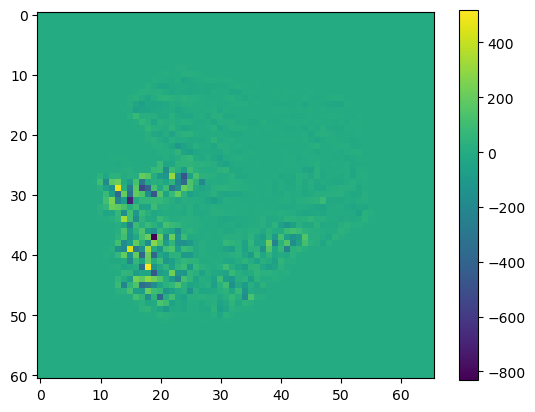

In [122]:
plt.imshow(diff4),plt.colorbar()

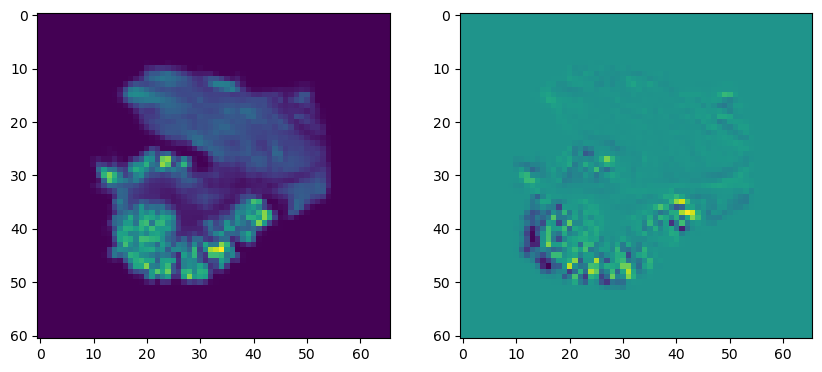

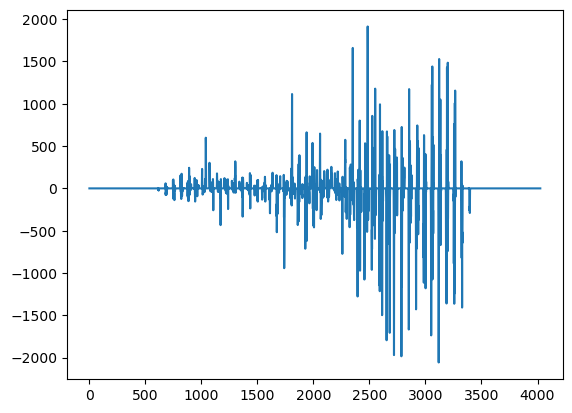

In [91]:
c_map = compose_mapping_chain_2d([mapping_img, mapping_img3, mapping_img4])
# c_map = compose_coordinate_mappings_2d(nb.load(mapping_img), nb.load(mapping_img2))
res0 = apply_coordinate_mapping_2d(nb.load(source_img), nb.load(mapping_img))
res1 = apply_coordinate_mapping_2d(res0, nb.load(mapping_img3))
res2 = apply_coordinate_mapping_2d(res1, nb.load(mapping_img4))

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(nb.load(comparison_img4).get_fdata())
plt.subplot(1,2,2)
plt.imshow(nb.load(comparison_img4).get_fdata()-res2.get_fdata())
plt.figure()
plt.plot((nb.load(comparison_img4).get_fdata()-res2.get_fdata()).flatten())



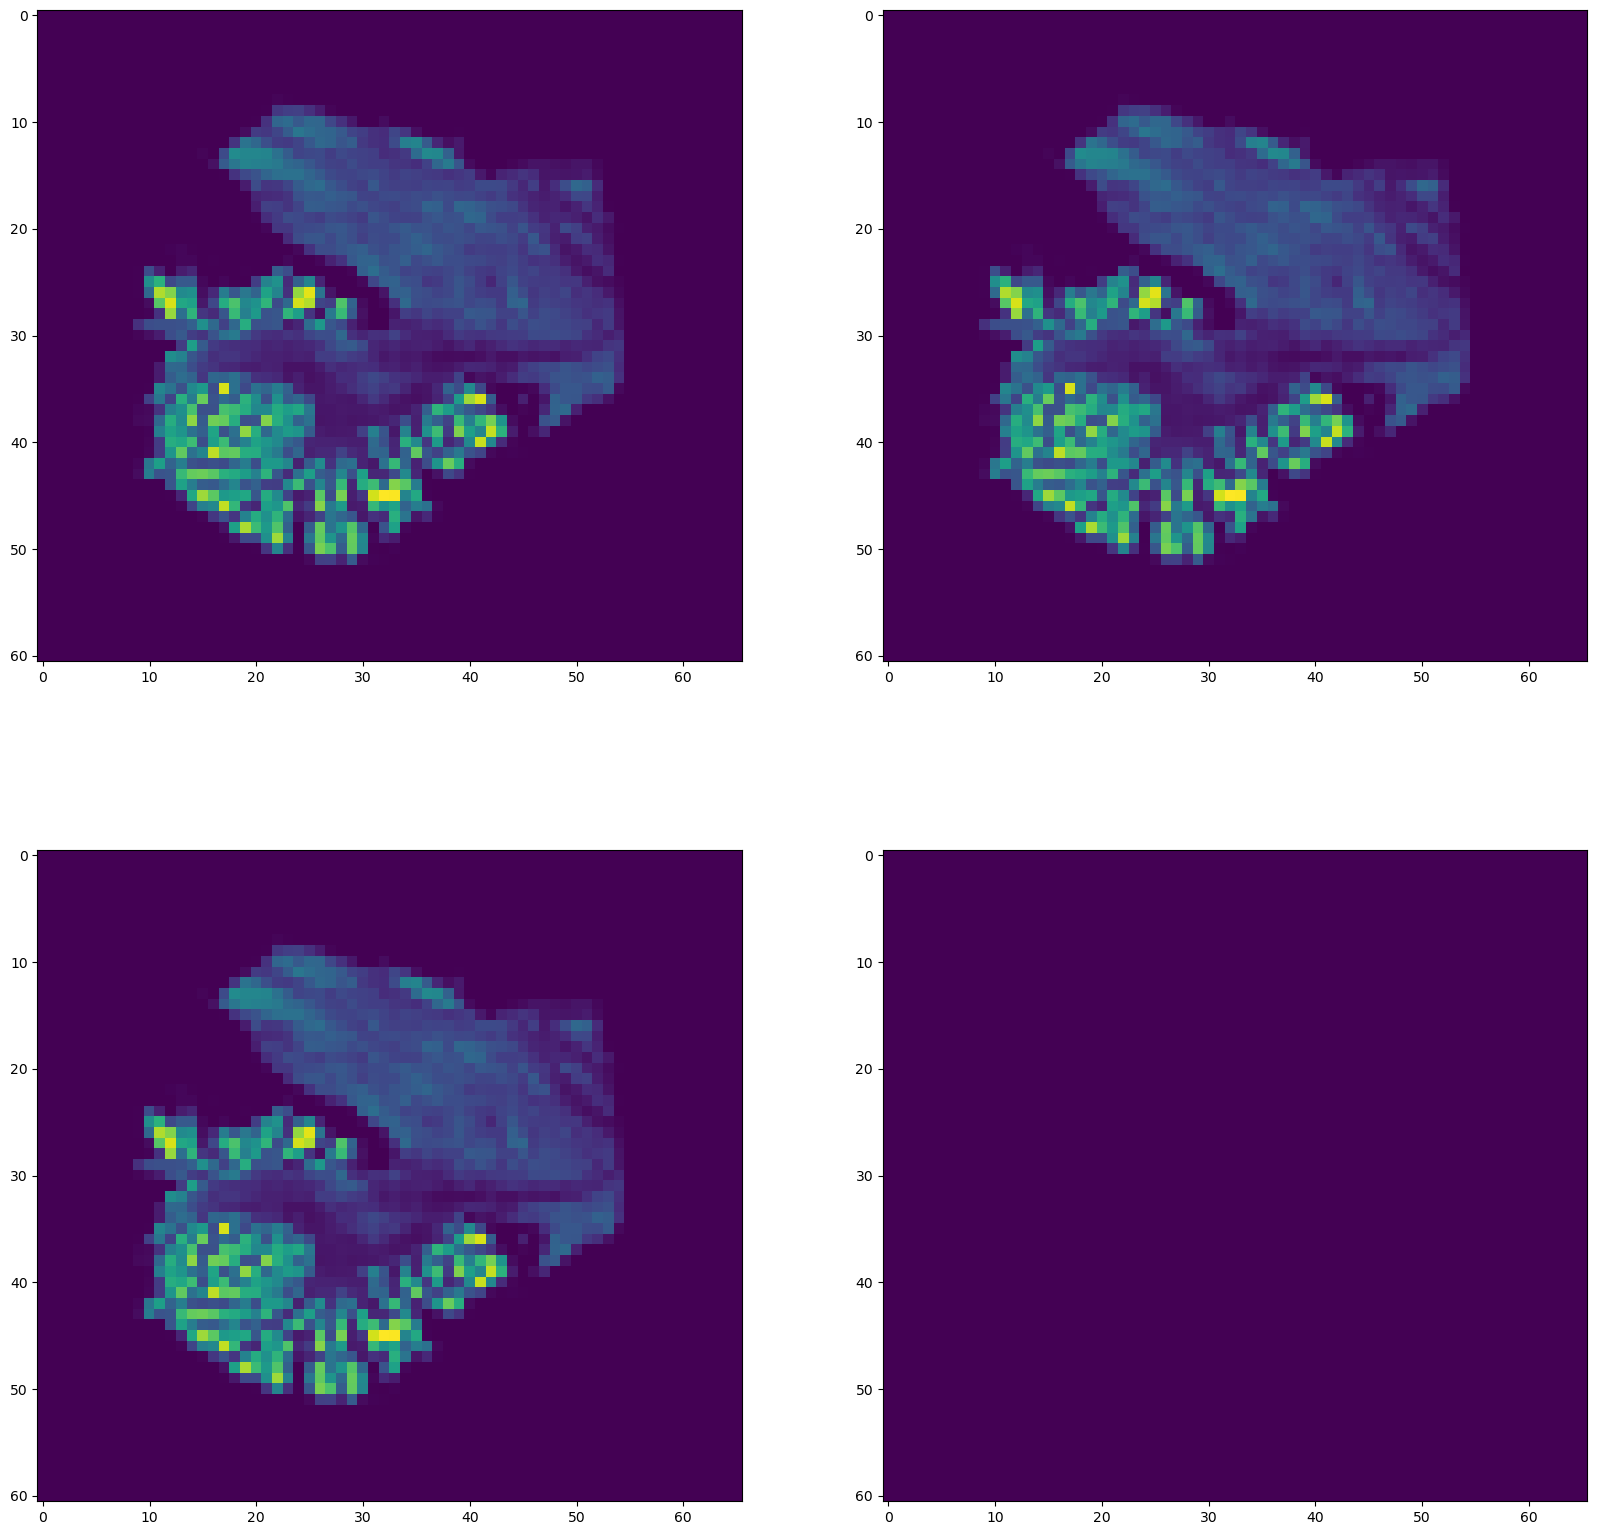

In [32]:
res = apply_coordinate_mapping_2d(nb.load(source_img), nb.load(mapping_img))
src_d = nb.load(source_img).get_fdata()
cmp_d = nb.load(comparison_img).get_fdata()
plt.figure(figsize=(20,20))
plt.subplot(2,2,1)
plt.imshow(src_d)
plt.subplot(2,2,2)
plt.imshow(res.get_fdata())
plt.subplot(2,2,3)
plt.imshow(cmp_d)
plt.subplot(2,2,4)
plt.imshow(res.get_fdata()-cmp_d)

In [148]:
import numpy as np
import nibabel as nb
from scipy.ndimage import map_coordinates


def apply_coordinate_mappings_cbstools(
    image,
    mapping_files,
    interpolation="nearest",
    padding="closest"
):

    img = nb.load(image)
    data = img.get_fdata()
    affine = img.affine
    hdr = img.header

    mappings = [nb.load(m).get_fdata() for m in mapping_files]
    ndim = mappings[0].shape[-1]

    out_shape = mappings[0].shape[:-1]
    output = np.zeros(out_shape, dtype=data.dtype)

    # determine interpolation order
    img_order = 0 if interpolation == "nearest" else 1

    # padding behavior for image sampling
    if padding == "closest":
        mode = "nearest"
        cval = 0
    elif padding == "zero":
        mode = "constant"
        cval = 0
    elif padding == "max":
        mode = "constant"
        cval = np.max(data)
    elif padding == "min":
        mode = "constant"
        cval = np.min(data)
    else:
        raise ValueError("Unknown padding")

    # deformation fields always use linear interpolation + closest padding
    def sample_def(field, coords):
        return map_coordinates(
            field,
            coords,
            order=1,
            mode="nearest"
        )

    # build coordinate grid
    grid = np.meshgrid(
        *[np.arange(s) for s in out_shape],
        indexing="ij"
    )

    coords = [g.astype(np.float64) for g in grid]

    # sequentially apply deformation fields
    for m in mappings:
        new_coords = []
        for d in range(ndim):
            sampled = sample_def(
                m[..., d],
                coords
            )
            new_coords.append(sampled)
        coords = new_coords

    # sample final image
    if data.ndim == ndim:
        output = map_coordinates(
            data,
            coords,
            order=img_order,
            mode=mode,
            cval=cval
        )
    else:
        output = np.zeros((*out_shape, data.shape[-1]))
        for t in range(data.shape[-1]):
            output[..., t] = map_coordinates(
                data[..., t],
                coords,
                order=img_order,
                mode=mode,
                cval=cval
            )

    return nb.Nifti1Image(output, affine, hdr)

In [149]:
gptres = apply_coordinate_mappings_cbstools(source_img, [mapping_img, mapping_img3, mapping_img4], interpolation="nearest", padding="closest")
print(np.max(nb.load(comparison_img4).get_fdata()-gptres.get_fdata()))

1025.499755859375


2739.538818359375


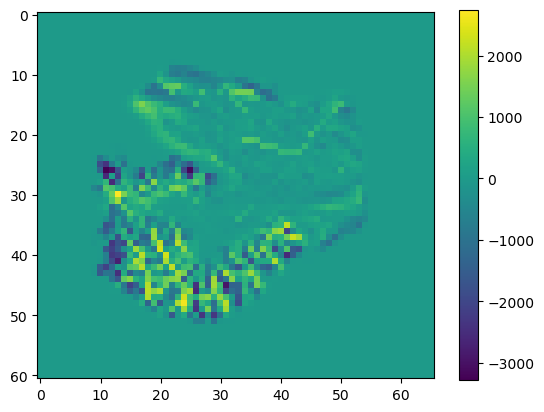

In [146]:
plt.imshow(nb.load(comparison_img4).get_fdata()-gptres.get_fdata()),plt.colorbar()
print(np.max(nb.load(comparison_img4).get_fdata()-gptres.get_fdata()))